# Training rollout sanity check

Runs a handful of steps with a freshly initialized PPO-RNN agent on 1 env and plots, per step:

1. **Global map** — whole 128×128 RGB map with spawn, target, current position, and trajectory so far
2. **Minimap RGB** — channels 0-2 of the observation (map colors with occlusion)
3. **Visibility mask** — channel 3 (white = visible, black = occluded)
4. **Target indicator** — channel 4 (single pixel at target if visible)
5. **Policy + state** — action-probability bar chart and a text panel of the scalar observation

Use this to verify the env/agent/obs pipeline is wired correctly before long training runs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from cogniland.config.env import setup_environment
setup_environment()

import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import jax
import jax.numpy as jnp

from cogniland.envs.registry import make_env
from cogniland.envs.env import TERRAIN_NAMES, NUM_ACTIONS, MINIMAP_RADIUS
from cogniland.agents.ppo_rnn import ActorCriticRNN

ACTION_NAMES = ["up", "down", "left", "right", "forage", "raft", "rope", "shoes"]
TOOL_NAMES = {0: "none", 1: "raft", 2: "rope", 3: "shoes"}

In [2]:
# Load the real env + agent config, force 1 env so we can plot one rollout clearly
env_cfg = OmegaConf.load("../configs/env/cogniland.yaml")
agent_cfg = OmegaConf.load("../configs/agent/ppo_rnn.yaml")
config = OmegaConf.merge(env_cfg, agent_cfg)
config.env.num_parallel_envs = 1
config.env.num_parallel_envs_eval = 1
config.seed = 7

# Map paths in the YAML are relative to the repo root; absolutise them
# so this notebook works regardless of its working directory.
REPO_ROOT = os.path.abspath("..")
config.env.train_maps = os.path.join(REPO_ROOT, "data", "maps", "train.pt")
config.env.val_maps   = os.path.join(REPO_ROOT, "data", "maps", "val.pt")
config.env.test_maps  = os.path.join(REPO_ROOT, "data", "maps", "test.pt")

NUM_STEPS = 8
print(OmegaConf.to_yaml(config.env))

map_size: 128
num_parallel_envs: 1
num_parallel_envs_eval: 1
max_steps: 1000
train_maps: /home/filippo/GitHub/Crusoe-Cogniland/data/maps/train.pt
val_maps: /home/filippo/GitHub/Crusoe-Cogniland/data/maps/val.pt
test_maps: /home/filippo/GitHub/Crusoe-Cogniland/data/maps/test.pt
minimap_max_ray: 22
occlude: true
clear_tolerance: 0.15
init_hp: 100
hp_max: 100
wood_max: 100
craft_cost: 100
terrain_vis_radius:
  ocean: 16
  deep_water: 12
  water: 10
  beach: 7
  sandy: 7
  grassland: 7
  forest: 5
  rocky: 10
  mountains: 22
min_spawn_target_manhattan: 0



In [3]:
# Build env + network (use the PPO-RNN network directly to avoid the select_action
# LSTM-carry cache, which is training-oriented).
env = make_env("cogniland-v0", config, train=False)
obs = env.reset(seed=int(config.seed))

TASK_EMB_DIM = int(config.task_embedding_dim)
LSTM = int(config.agent.lstm_size)
HIDDEN = int(config.agent.hidden_size)
IN_CHANNELS = obs["minimap"].shape[1]  # 5 = RGB + visibility + target

network = ActorCriticRNN(
    num_actions=NUM_ACTIONS,
    lstm_size=LSTM,
    hidden_size=HIDDEN,
    task_embedding_dim=TASK_EMB_DIM,
)

rng = jax.random.PRNGKey(int(config.seed))
rng, init_rng = jax.random.split(rng)

dummy_minimap = jnp.zeros((1, IN_CHANNELS, 45, 45))
dummy_scalars = jnp.zeros((1, 6))
dummy_task_emb = jnp.zeros((1, TASK_EMB_DIM))
dummy_carry = (jnp.zeros((1, LSTM)), jnp.zeros((1, LSTM)))
params = network.init(init_rng, dummy_minimap, dummy_scalars, dummy_task_emb, dummy_carry)

@jax.jit
def forward(params, minimap, scalars, task_emb, carry):
    return network.apply(params, minimap, scalars, task_emb, carry)

print("env.num_envs   :", env.num_envs)
print("obs keys       :", list(obs.keys()))
print("minimap shape  :", obs["minimap"].shape, obs["minimap"].dtype)
print("  channels 0-2 : RGB,  channel 3: visibility,  channel 4: target")
print("scalars        :", obs["scalars"].shape, obs["scalars"].dtype)
print("task_emb       :", obs["task_embedding"].shape)
print("spawn          :", (int(env.env.spawn_r[0]), int(env.env.spawn_c[0])))
print("target         :", (int(env.env.target_r[0]), int(env.env.target_c[0])))

env.num_envs   : 1
obs keys       : ['minimap', 'scalars', 'task_embedding']
minimap shape  : (1, 5, 45, 45) float32
  channels 0-2 : RGB,  channel 3: visibility,  channel 4: target
scalars        : (1, 6) float32
task_emb       : (1, 7)
spawn          : (109, 76)
target         : (80, 45)


In [4]:
# Run NUM_STEPS steps, recording everything we want to plot.
carry = (jnp.zeros((1, LSTM)), jnp.zeros((1, LSTM)))

records = []

# Snapshot the initial state before we step
def snapshot(env, obs, logits, value, action, reward=None, done=False):
    return {
        "pos":     (int(env.env.pos_r[0]), int(env.env.pos_c[0])),
        "target":  (int(env.env.target_r[0]), int(env.env.target_c[0])),
        "spawn":   (int(env.env.spawn_r[0]), int(env.env.spawn_c[0])),
        "map_idx": int(env.env.map_idx[0]),
        "hp":      float(env.env.hp[0]),
        "wood":    int(env.env.wood[0]),
        "tool":    int(env.env.tool[0]),
        "steps":   int(env.env.steps[0]),
        "minimap": np.asarray(obs["minimap"][0]),  # [3, 45, 45]
        "scalars": np.asarray(obs["scalars"][0]),   # [6]
        "logits":  np.asarray(logits[0]),           # [8]
        "value":   float(value[0]),
        "action":  int(action),
        "reward":  None if reward is None else float(reward),
        "done":    bool(done),
    }

for t in range(NUM_STEPS):
    minimap = jnp.asarray(obs["minimap"])
    scalars = jnp.asarray(obs["scalars"])
    task_emb = jnp.asarray(obs["task_embedding"])

    logits, value, new_carry = forward(params, minimap, scalars, task_emb, carry)
    rng, sub = jax.random.split(rng)
    action = int(jax.random.categorical(sub, logits)[0])

    rec = snapshot(env, obs, logits, value, action)
    obs, rewards, dones, info = env.step(np.array([action], dtype=np.int32))
    rec["reward"] = float(rewards[0])
    rec["done"] = bool(dones[0])
    records.append(rec)

    carry = new_carry
    if dones[0]:
        print(f"step {t}: episode ended (hp={env.env.hp[0]:.1f}); env auto-resets")

print(f"Recorded {len(records)} transitions")
for r in records:
    print(f"  t={r['steps']:>3}  pos={r['pos']}  hp={r['hp']:6.2f}  wood={r['wood']:>3}  "
          f"tool={TOOL_NAMES[r['tool']]:>5}  a={ACTION_NAMES[r['action']]:>6}  r={r['reward']:+.3f}  done={r['done']}")

Recorded 8 transitions
  t=  0  pos=(109, 76)  hp=100.00  wood=  0  tool= none  a=  raft  r=-0.010  done=False
  t=  1  pos=(109, 76)  hp=100.00  wood=  0  tool= none  a=    up  r=+0.040  done=False
  t=  2  pos=(108, 76)  hp= 99.00  wood=  0  tool= none  a=forage  r=-0.010  done=False
  t=  3  pos=(108, 76)  hp= 99.00  wood=  0  tool= none  a=  raft  r=-0.010  done=False
  t=  4  pos=(108, 76)  hp= 99.00  wood=  0  tool= none  a=  rope  r=-0.010  done=False
  t=  5  pos=(108, 76)  hp= 99.00  wood=  0  tool= none  a=  rope  r=-0.010  done=False
  t=  6  pos=(108, 76)  hp= 99.00  wood=  0  tool= none  a= right  r=-0.060  done=False
  t=  7  pos=(108, 77)  hp= 98.00  wood=  0  tool= none  a=    up  r=+0.040  done=False


## Per-step visualization

One row per step. Left: the global map with trajectory (red), spawn (green circle), target (gold star), current position (red dot). Middle: the minimap observation the CNN receives. Right: policy action probabilities + scalar observation state.

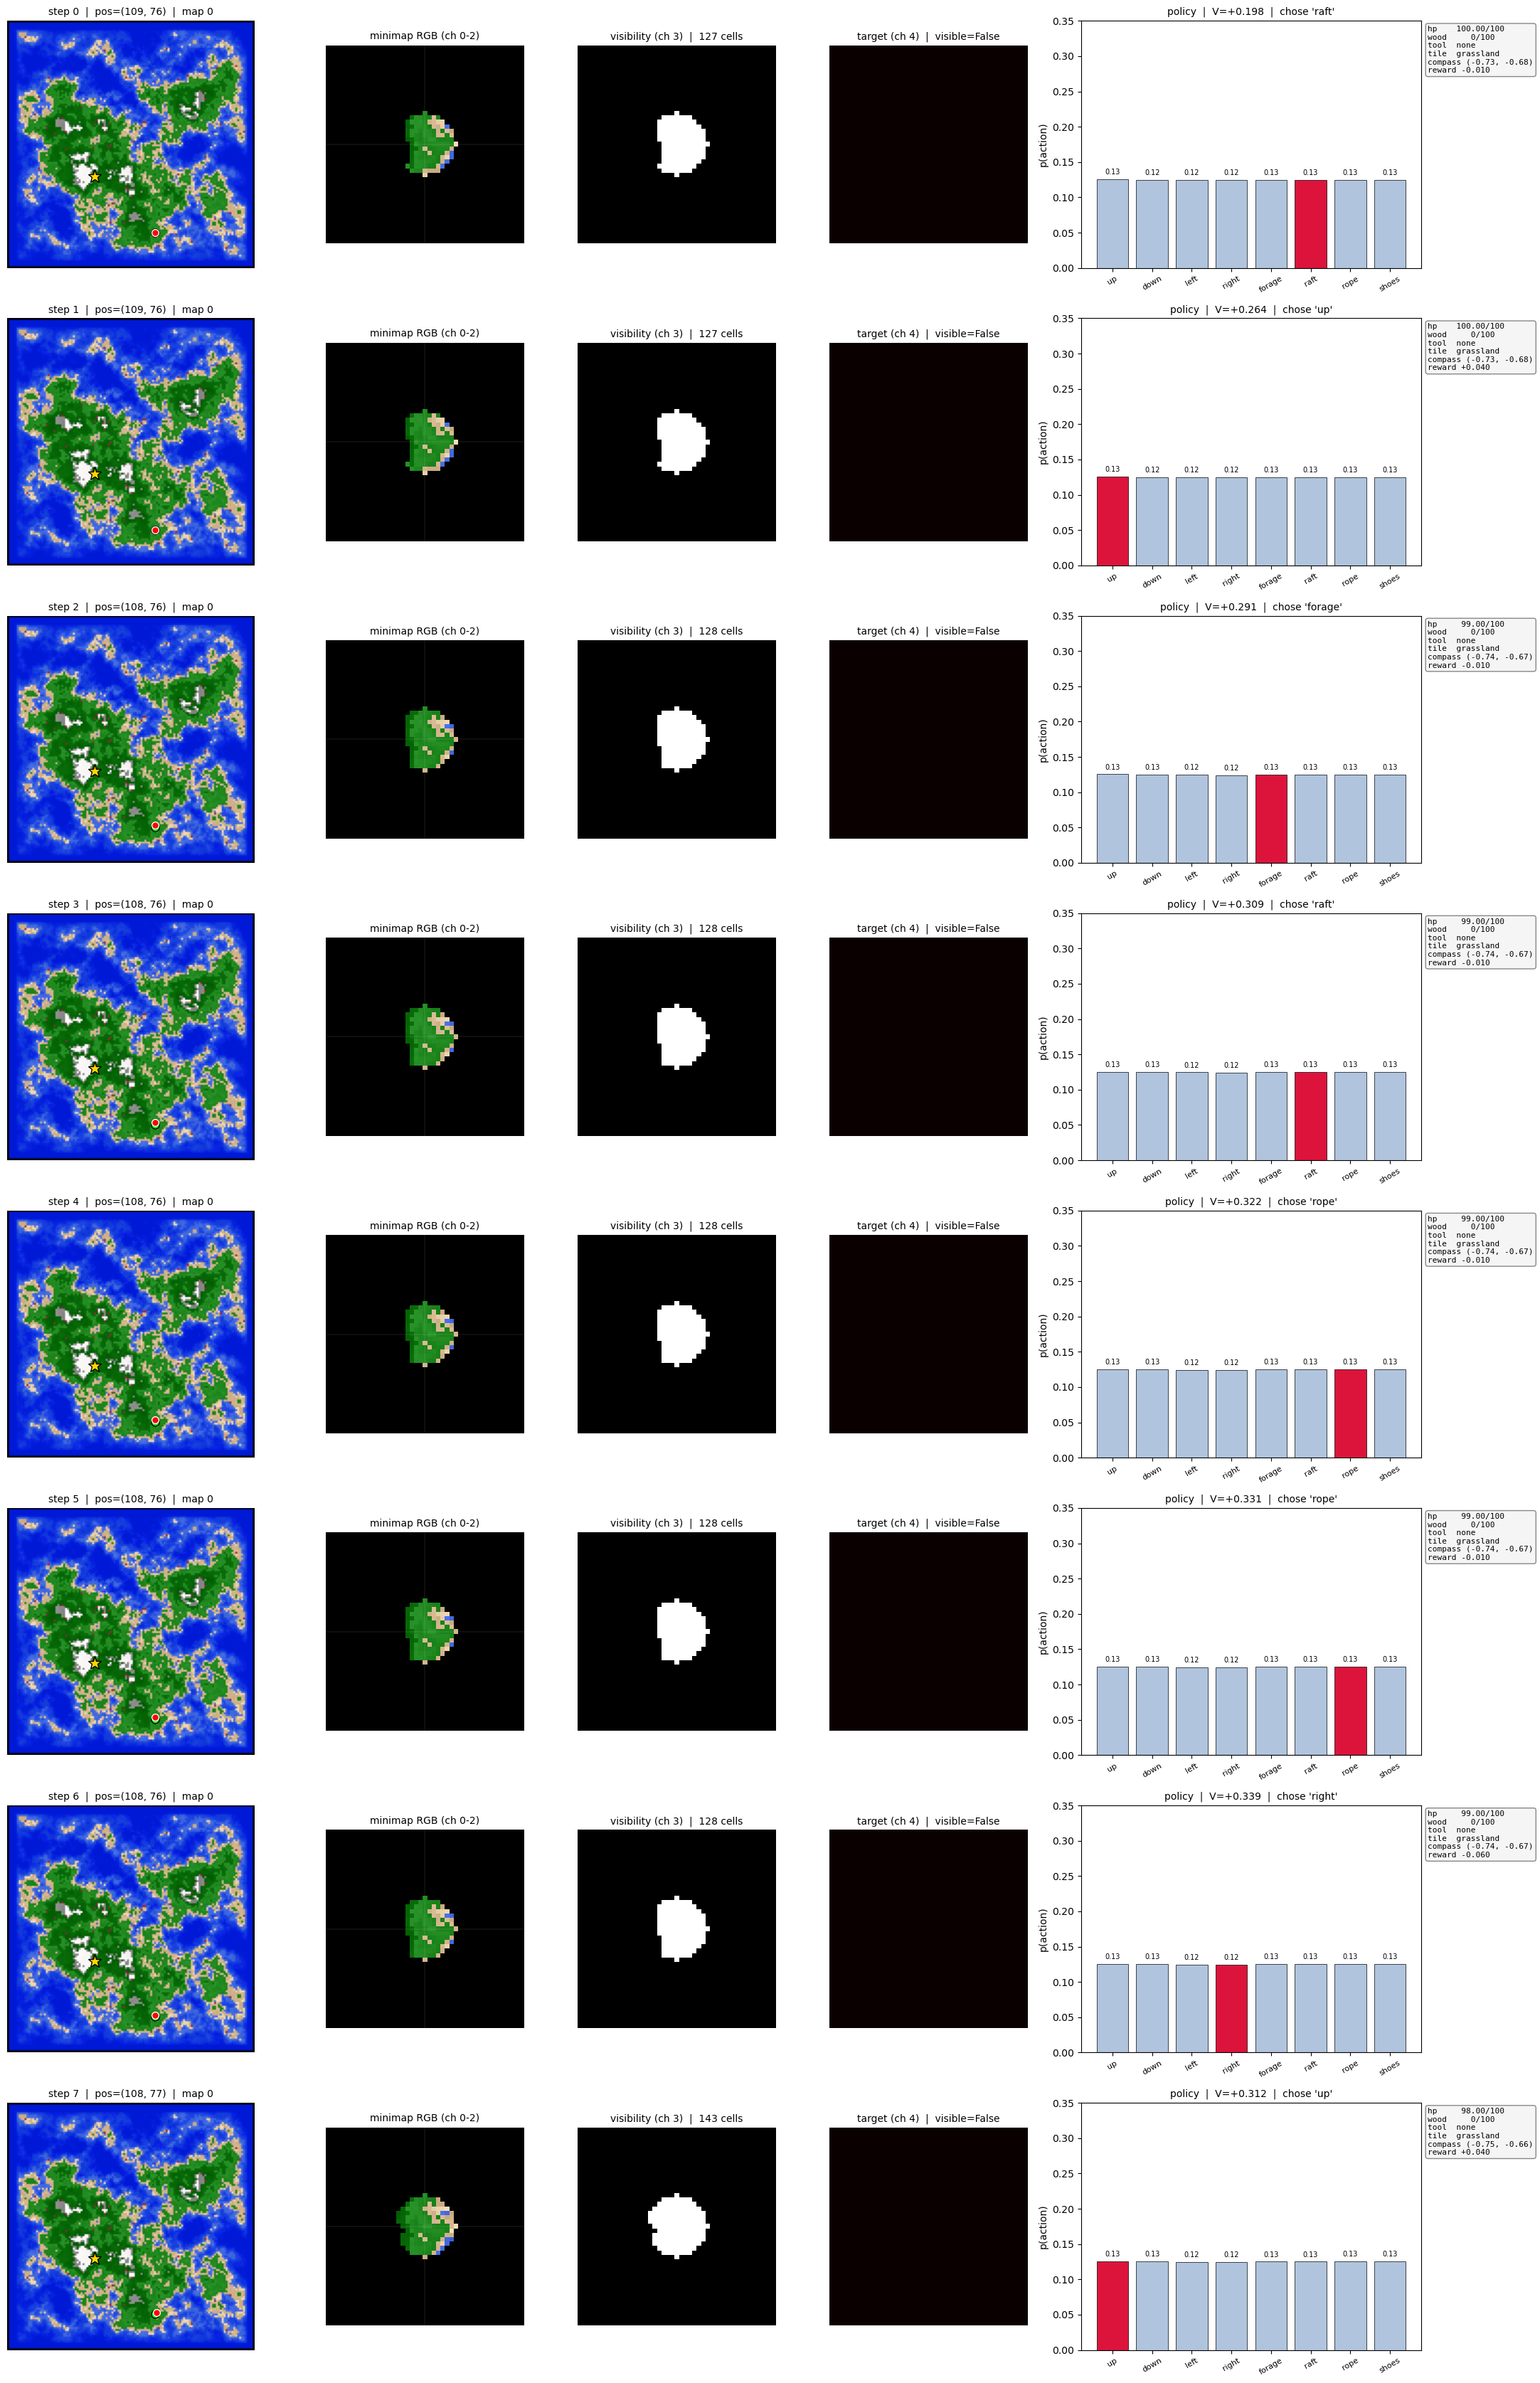

In [5]:
# Grab the underlying raw map to use as the 'global map' backdrop.
rgb_maps = env.env._rgb  # [N, 128, 128, 3] uint8

TERRAIN_NAMES_EXT = TERRAIN_NAMES + ["berry"]  # tile class 9 = berry

n = len(records)
fig, axes = plt.subplots(n, 5, figsize=(22, 4.2 * n),
                         gridspec_kw={"width_ratios": [1.0, 0.7, 0.7, 0.7, 1.2]})
if n == 1:
    axes = axes[np.newaxis, :]

# Reconstruct trajectory by episode (env auto-resets on done)
ep_of = []
cur = 0
for i, r in enumerate(records):
    if i > 0 and (records[i - 1]["done"] or r["map_idx"] != records[i - 1]["map_idx"]):
        cur += 1
    ep_of.append(cur)

traj_by_episode = {}
for i, r in enumerate(records):
    traj_by_episode.setdefault(ep_of[i], []).append(r["pos"])

for i, r in enumerate(records):
    # --- 1) Global map with trajectory ---
    ax = axes[i, 0]
    ax.imshow(rgb_maps[r["map_idx"]])
    traj = traj_by_episode[ep_of[i]]
    cutoff = traj.index(r["pos"]) + 1
    traj_so_far = traj[:cutoff]
    if len(traj_so_far) > 1:
        ys, xs = zip(*traj_so_far)
        ax.plot(xs, ys, "r-", linewidth=1.5, alpha=0.9)
    ax.plot(r["spawn"][1], r["spawn"][0], "o", color="lime", markersize=8, markeredgecolor="k")
    ax.plot(r["target"][1], r["target"][0], "*", color="gold", markersize=14, markeredgecolor="k")
    ax.plot(r["pos"][1], r["pos"][0], "o", color="red", markersize=7, markeredgecolor="white")
    ax.set_title(f"step {r['steps']}  |  pos={r['pos']}  |  map {r['map_idx']}", fontsize=10)
    ax.axis("off")

    mm = r["minimap"]  # [5, 45, 45]

    # --- 2) Channels 0-2: RGB ---
    ax = axes[i, 1]
    rgb = np.transpose(mm[:3], (1, 2, 0))
    ax.imshow(np.clip(rgb, 0, 1))
    ax.axhline(MINIMAP_RADIUS, color="white", linewidth=0.3, alpha=0.3)
    ax.axvline(MINIMAP_RADIUS, color="white", linewidth=0.3, alpha=0.3)
    ax.set_title("minimap RGB (ch 0-2)", fontsize=10)
    ax.axis("off")

    # --- 3) Channel 3: visibility mask ---
    ax = axes[i, 2]
    ax.imshow(mm[3], cmap="gray", vmin=0, vmax=1)
    visible_cells = int(mm[3].sum())
    ax.set_title(f"visibility (ch 3)  |  {visible_cells} cells", fontsize=10)
    ax.axis("off")

    # --- 4) Channel 4: target indicator ---
    ax = axes[i, 3]
    ax.imshow(mm[4], cmap="hot", vmin=0, vmax=1)
    target_visible = bool(mm[4].sum() > 0)
    ax.set_title(f"target (ch 4)  |  visible={target_visible}", fontsize=10)
    ax.axis("off")

    # --- 5) Policy bar chart + state text ---
    ax = axes[i, 4]
    logits = r["logits"]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    colors = ["lightsteelblue"] * NUM_ACTIONS
    colors[r["action"]] = "crimson"
    bars = ax.bar(ACTION_NAMES, probs, color=colors, edgecolor="k", linewidth=0.5)
    ax.set_ylim(0, max(0.35, probs.max() * 1.15))
    ax.set_ylabel("p(action)")
    ax.set_title(f"policy  |  V={r['value']:+.3f}  |  chose '{ACTION_NAMES[r['action']]}'", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    for b, p in zip(bars, probs):
        ax.text(b.get_x() + b.get_width() / 2, p + 0.005, f"{p:.2f}",
                ha="center", va="bottom", fontsize=7)

    sc = r["scalars"]
    # tile class is now 0..9 normalized by /9
    tile_i = int(round(float(sc[2]) * 9))
    tile_i = max(0, min(len(TERRAIN_NAMES_EXT) - 1, tile_i))
    state_txt = (
        f"hp    {r['hp']:6.2f}/100\n"
        f"wood  {r['wood']:>4d}/100\n"
        f"tool  {TOOL_NAMES[r['tool']]}\n"
        f"tile  {TERRAIN_NAMES_EXT[tile_i]}\n"
        f"compass ({sc[0]:+.2f}, {sc[1]:+.2f})\n"
        f"reward {r['reward']:+.3f}"
    )
    ax.text(1.02, 0.98, state_txt, transform=ax.transAxes,
            va="top", ha="left", family="monospace", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5f5f5", edgecolor="#888"))

plt.tight_layout()
plt.show()

## What to verify visually

- **Map column**: red position dot should start on the green spawn circle and advance one cell per row. Trajectory line should match the sequence of positions.
- **Minimap RGB**: center pixel is always the player's cell; unseen cells are black. Target is NOT drawn in RGB anymore — it's in channel 4.
- **Visibility mask**: white region grows/shrinks with terrain-dependent sight radius (mountains = 22, forest = 5).
- **Target channel**: a single bright pixel if the target is within the visible region, otherwise all zero.
- **Policy column**: with fresh (uninitialized) weights the policy should be ~uniform (all bars ≈0.125). The highlighted bar is the sampled action.
- **State panel**: `compass` magnitude ≈1 (unit vector), `hp` decreases per step by terrain drain (0 on berry, 1 on grassland, 3 on forest, etc.), `tile` updates as you cross cells and should read `berry` if you step on a berry overlay.